<a href="https://colab.research.google.com/github/AhmadMuhaiminKamil/ImageProcessing/blob/main/ImageConvolution/Image_Convolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gambar berhasil dimuat!


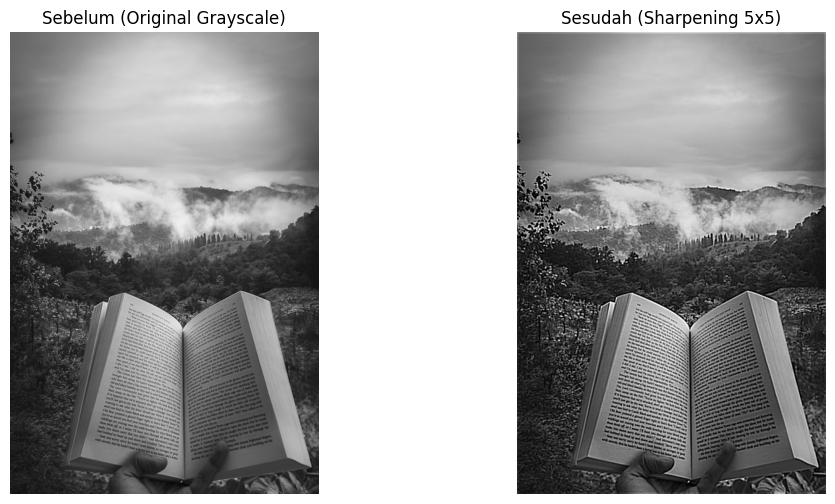

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

# --- STEP 1: Load Gambar dengan Header Browser ---
url = "https://images.unsplash.com/photo-1541963463532-d68292c34b19?w=500"
headers = {'User-Agent': 'Mozilla/5.0'}

try:
    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert('L')
    img_array = np.array(img)
    print("Gambar berhasil dimuat!")
except Exception as e:
    print(f"Gagal memuat gambar: {e}")
    img_array = np.indices((300, 300)).sum(axis=0) % 2 * 255

# --- STEP 2: Definisikan Kernel Sharpening 5x5 ---
kernel = np.array([
    [-1, -1, -1, -1, -1],
    [-1,  2,  2,  2, -1],
    [-1,  2,  8,  2, -1],
    [-1,  2,  2,  2, -1],
    [-1, -1, -1, -1, -1]
]) / 8.0

# --- STEP 3: Fungsi Konvolusi Manual ---
def manual_convolution(image, kernel):
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    pad_h, pad_w = ker_h // 2, ker_w // 2

    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)

    # Loop Utama
    for i in range(img_h):
        for j in range(img_w):
            roi = padded_img[i:i+ker_h, j:j+ker_w]
            val = np.sum(roi * kernel)
            output[i, j] = val

    return np.clip(output, 0, 255).astype(np.uint8)

# --- STEP 4: Eksekusi ---
result = manual_convolution(img_array, kernel)

# --- STEP 5: Tampilkan Hasil ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Sebelum (Original Grayscale)")
plt.imshow(img_array, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Sesudah (Sharpening 5x5)")
plt.imshow(result, cmap='gray')
plt.axis('off')
plt.show()